# Notebook 2 — K-Means Clustering (Spatial Quality Labels)

## COS40007 Artificial Intelligence Engineering — Theme 5

**Goal:** Cluster 5G grid squares into 3 quality tiers (Poor / Medium / Good)
using K-Means on spatial aggregates of network-quality features.

| Step | Task |
|------|------|
| 0 | Environment & paths |
| 1 | Load `cleaned_5g_data.csv` from Notebook 1 |
| 2 | Reconstruct base features & aggregate per `square_id` |
| 3 | K-Means (k=3) + deterministic label mapping |
| 4 | Evaluation & visualisation (spatial, scatter, PCA) |
| 5 | Export `map_data.csv` + model artefacts |

**Frontend contract:** `backend/data/map_data.csv` with columns
`lat`, `lng`, `cluster` (∈ {0, 1, 2}).

**Note on feature availability:**
Notebook 1's feature-selection step (>0.95 correlation) dropped several
base columns (`download_mbps`, `upload_mbps`, `avg_latency`).
We reconstruct them from surviving proxies:
- `download_mbps` ← `np.expm1(log_download)`
- `avg_latency`   ← `avg_latency_lag1` (mean per square is nearly identical)
- `cwnd`          ← raw `CWnd` column (survived selection)

---
## Step 0 — Environment & Project Paths

In [67]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="muted")

BASE_DIR    = Path(".")
DATA_DIR    = BASE_DIR / "data"
OUTPUT_DIR  = BASE_DIR / "data"
MODELS_DIR  = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory  : {DATA_DIR.resolve()}")
print(f"Models output   : {MODELS_DIR.resolve()}")

Data directory  : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\data
Models output   : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models


---
## Step 1 — Load Cleaned Data

In [68]:
# ── 1a. Load the cleaned dataset ──────────────────────────
df = pd.read_csv(DATA_DIR / "cleaned_5g_data.csv", low_memory=False)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique trucks    : {df['truck'].nunique()}")
print(f"Unique square_ids: {df['square_id'].nunique()}")

# ── 1b. Reconstruct base network features ────────────────
# These were dropped in Notebook 1's feature-selection step (|r|>0.95)
# but are needed for interpretable spatial clustering.
df["download_mbps"] = np.expm1(df["log_download"])
df["avg_latency"]   = df["avg_latency_lag1"]
df["cwnd"]          = pd.to_numeric(df["CWnd"], errors="coerce").fillna(0)

for col in ["download_mbps", "avg_latency", "cwnd", "retransmission_rate", "jitter"]:
    print(f"  {col:25s}  mean={df[col].mean():.4f}  null={df[col].isna().sum()}")

Loaded: 2,041,013 rows × 63 columns
Unique trucks    : 11
Unique square_ids: 227
  download_mbps              mean=18.6606  null=0
  avg_latency                mean=172.5503  null=8
  cwnd                       mean=0.0111  null=0
  retransmission_rate        mean=0.2097  null=0
  jitter                     mean=35.5578  null=0


---
## Step 2 — Spatial Aggregation & Feature Selection

Aggregate **per `square_id`**, computing summary statistics for each
grid square. Only **network-quality** features are selected for
clustering — no temporal features (hour_sin, dow, is_weekend, etc.)
to avoid confounding spatial quality with time-of-day effects.

In [69]:
# ── 2a. Aggregate one row per grid square ─────────────────
agg_dict = {
    "latitude":            "mean",
    "longitude":           "mean",
    "download_mbps":       ["mean", "std"],
    "avg_latency":         ["mean", "std"],
    "cwnd":                "mean",
    "retransmission_rate": "mean",
    "jitter":              "mean",
    "latency_spread":      "mean",
    "congestion_indicator": "mean",
}

grid = df.groupby("square_id").agg(agg_dict)
grid.columns = ["_".join(col).strip("_") for col in grid.columns]
grid.rename(columns={
    "latitude_mean":  "lat",
    "longitude_mean": "lng",
}, inplace=True)
grid.reset_index(inplace=True)

print(f"Grid squares: {len(grid)}")
print(f"Aggregated columns: {list(grid.columns)}")
grid.describe().round(3)

Grid squares: 227
Aggregated columns: ['square_id', 'lat', 'lng', 'download_mbps_mean', 'download_mbps_std', 'avg_latency_mean', 'avg_latency_std', 'cwnd_mean', 'retransmission_rate_mean', 'jitter_mean', 'latency_spread_mean', 'congestion_indicator_mean']


,lat,lng,download_mbps_mean,download_mbps_std,avg_latency_mean,avg_latency_std,cwnd_mean,retransmission_rate_mean,jitter_mean,latency_spread_mean,congestion_indicator_mean
count,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000,227.000
mean,-37.754,144.802,18.632,12.930,162.678,158.424,0.011,0.217,36.159,43.773,0.061
std,0.034,0.031,7.035,4.233,112.661,88.893,0.004,0.079,21.912,22.735,0.086
min,-37.828,144.750,0.000,0.000,28.580,2.726,0.000,0.000,1.508,17.409,0.000
25%,-37.780,144.776,15.423,10.660,75.021,81.671,0.008,0.164,17.578,26.037,0.008
50%,-37.750,144.801,18.097,13.039,123.467,146.100,0.011,0.212,32.023,37.080,0.031
75%,-37.722,144.824,20.999,15.708,236.826,234.831,0.013,0.265,52.352,53.539,0.087
max,-37.701,144.884,57.755,27.316,543.771,354.920,0.028,0.788,132.876,130.738,0.750


---
## Step 3 — Optimised Clustering Pipeline

### Feature selection (9 → 5 core features)
The original 9 aggregated features contain **high pairwise correlations**:
- `download_mbps_std` correlates with `download_mbps_mean`
- `avg_latency_std` correlates with `avg_latency_mean`
- `latency_spread_mean` overlaps with `jitter_mean`
- `congestion_indicator_mean` is a composite of latency + retransmission

Retaining correlated features inflates dimensionality without adding
discriminative power, producing diffuse cluster boundaries and a low
silhouette score. We reduce to **5 independent quality dimensions**:

| Feature | Quality dimension |
|---|---|
| `download_mbps_mean` | Throughput |
| `avg_latency_mean` | Delay |
| `cwnd_mean` | Congestion window |
| `retransmission_rate_mean` | Reliability (packet loss) |
| `jitter_mean` | Stability |

### Preprocessing pipeline
1. **Winsorise** at P5 / P95 → limit outlier influence on centroids
2. **Log1p-transform** right-skewed features (`retransmission_rate`, `jitter`)
3. **RobustScaler** (median / IQR based) → less sensitive to residual outliers
4. **PCA** → auto-select 2 or 3 components by silhouette score

### Clustering
- **K-Means (k = 3, n_init = 50)** with deterministic relabelling
- **GMM (k = 3)** as a probabilistic alternative for comparison

In [70]:
# ── 3a. Feature selection, preprocessing, scale, & PCA ────
# 5 core network-quality features (dropped 4 correlated/redundant):
#   DROPPED: download_mbps_std         (high r with download_mbps_mean)
#            avg_latency_std            (high r with avg_latency_mean)
#            latency_spread_mean        (high r with jitter_mean)
#            congestion_indicator_mean  (composite, collinear)
CLUSTER_FEATURES = [
    "download_mbps_mean",
    "avg_latency_mean",
    "cwnd_mean",
    "retransmission_rate_mean",
    "jitter_mean",
]

X_pre = grid[CLUSTER_FEATURES].fillna(0).copy()

# ── Winsorise at P5 / P95 to tame outliers ───────────────
for col in X_pre.columns:
    lo, hi = np.percentile(X_pre[col], [5, 95])
    X_pre[col] = np.clip(X_pre[col], lo, hi)

# ── Log1p on right-skewed features ───────────────────────
for col in ["retransmission_rate_mean", "jitter_mean"]:
    if (X_pre[col] >= 0).all():
        X_pre[col] = np.log1p(X_pre[col])

# ── RobustScaler (median / IQR, less outlier-sensitive) ──
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_pre)

# ── PCA: auto-select best dimensionality by silhouette ───
print("PCA dimensionality search:")
best_sil_pca, N_COMPONENTS = -1, 2
for n_try in [2, 3]:
    _pca = PCA(n_components=n_try, random_state=42)
    _X = _pca.fit_transform(X_scaled)
    _km = KMeans(n_clusters=3, random_state=42, n_init=50)
    _s = silhouette_score(_X, _km.fit_predict(_X))
    var_pct = _pca.explained_variance_ratio_.sum()
    print(f"  PCA({n_try}): silhouette = {_s:.3f}  variance = {var_pct:.1%}")
    if _s > best_sil_pca:
        best_sil_pca, N_COMPONENTS = _s, n_try

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n→ Selected PCA({N_COMPONENTS})  (best silhouette = {best_sil_pca:.3f})")
print(f"  Features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}")
print(f"\nPCA explained variance per component:")
for i, (var, cum) in enumerate(zip(
    pca.explained_variance_ratio_,
    np.cumsum(pca.explained_variance_ratio_),
)):
    print(f"  PC{i+1}: {var:.1%}  (cumulative: {cum:.1%})")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.1%}")

PCA dimensionality search:
  PCA(2): silhouette = 0.412  variance = 86.7%
  PCA(3): silhouette = 0.368  variance = 94.2%

→ Selected PCA(2)  (best silhouette = 0.412)
  Features (5): ['download_mbps_mean', 'avg_latency_mean', 'cwnd_mean', 'retransmission_rate_mean', 'jitter_mean']

PCA explained variance per component:
  PC1: 57.4%  (cumulative: 57.4%)
  PC2: 29.3%  (cumulative: 86.7%)
Total variance retained: 86.7%


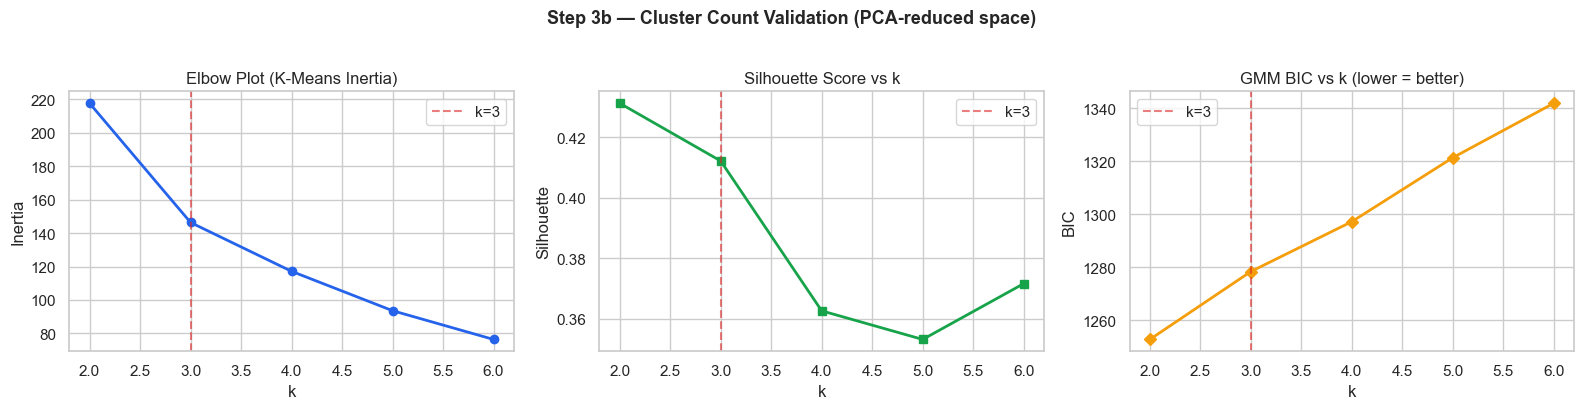

Silhouette scores: {2: '0.431', 3: '0.412', 4: '0.363', 5: '0.353', 6: '0.372'}
Best k by silhouette: 2
Best k by BIC:        2


In [71]:
# ── 3b. Elbow plot + Silhouette sweep → validate k=3 ─────
K_RANGE = range(2, 7)
inertias, sil_scores, bics = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_pca)
    bics.append(gmm.bic(X_pca))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(K_RANGE), inertias, "o-", color="#2563eb", lw=2)
axes[0].set(title="Elbow Plot (K-Means Inertia)", xlabel="k", ylabel="Inertia")
axes[0].axvline(3, ls="--", color="#dc2626", alpha=0.6, label="k=3")
axes[0].legend()

axes[1].plot(list(K_RANGE), sil_scores, "s-", color="#17a34a", lw=2)
axes[1].set(title="Silhouette Score vs k", xlabel="k", ylabel="Silhouette")
axes[1].axvline(3, ls="--", color="#dc2626", alpha=0.6, label="k=3")
axes[1].legend()

axes[2].plot(list(K_RANGE), bics, "D-", color="#f59e0b", lw=2)
axes[2].set(title="GMM BIC vs k (lower = better)", xlabel="k", ylabel="BIC")
axes[2].axvline(3, ls="--", color="#dc2626", alpha=0.6, label="k=3")
axes[2].legend()

fig.suptitle("Step 3b — Cluster Count Validation (PCA-reduced space)",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"Silhouette scores: {dict(zip(K_RANGE, [f'{s:.3f}' for s in sil_scores]))}")
print(f"Best k by silhouette: {list(K_RANGE)[np.argmax(sil_scores)]}")
print(f"Best k by BIC:        {list(K_RANGE)[np.argmin(bics)]}")

In [72]:
# ── 3c. K-Means on PCA components ─────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
grid["cluster_raw"] = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, grid["cluster_raw"])
print(f"K-Means silhouette score (PCA-reduced): {sil:.3f}")
print(f"Raw cluster sizes:\n{grid['cluster_raw'].value_counts().sort_index()}")

# ── 3d. GMM comparison on same PCA space ──────────────────
gmm = GaussianMixture(n_components=3, random_state=42, n_init=5)
gmm_labels = gmm.fit_predict(X_pca)
sil_gmm = silhouette_score(X_pca, gmm_labels)
print(f"\nGMM  silhouette score (PCA-reduced): {sil_gmm:.3f}")
print(f"GMM  BIC: {gmm.bic(X_pca):.1f}")

# ── 3e. Inspect cluster profiles via original features ────
# (centroids are in PCA space; use cluster means for interpretability)
for label_col, name in [("cluster_raw", "K-Means"), ("gmm_label", "GMM")]:
    if name == "GMM":
        grid["gmm_label"] = gmm_labels
    print(f"\n{name} cluster profiles (original-scale means):")
    for cid in sorted(grid[label_col].unique()):
        sub = grid[grid[label_col] == cid]
        print(f"  Cluster {cid}: n={len(sub):3d}  "
              f"DL={sub['download_mbps_mean'].mean():.1f} Mbps  "
              f"Lat={sub['avg_latency_mean'].mean():.1f} ms  "
              f"Retrans={sub['retransmission_rate_mean'].mean():.4f}")

# ── 3f. Select winner & deterministic re-labelling ────────
WINNER = "K-Means" if sil >= sil_gmm else "GMM"
print(f"\n🏆 Winner: {WINNER}  (silhouette {max(sil, sil_gmm):.3f})")

if WINNER == "GMM":
    grid["cluster_raw"] = gmm_labels
    sil = sil_gmm

# Rank by composite score: higher download + lower latency = better.
centroid_profiles = grid.groupby("cluster_raw")[["download_mbps_mean", "avg_latency_mean"]].mean()
centroid_profiles["_quality_score"] = (
    centroid_profiles["download_mbps_mean"] - centroid_profiles["avg_latency_mean"]
)
sorted_labels = centroid_profiles["_quality_score"].sort_values().index.tolist()
remap = {old: new for new, old in enumerate(sorted_labels)}  # worst→0, best→2

grid["cluster"] = grid["cluster_raw"].map(remap)

LABEL_MAP = {0: "Yếu (Poor)", 1: "Trung bình (Medium)", 2: "Tốt (Good)"}
print("\nDeterministic cluster profiles (0=Poor → 2=Good):")
for cid in sorted(grid["cluster"].unique()):
    sub = grid[grid["cluster"] == cid]
    print(f"  Cluster {cid} — {LABEL_MAP[cid]}:")
    print(f"    squares              = {len(sub)}")
    print(f"    mean download (Mbps) = {sub['download_mbps_mean'].mean():.2f}")
    print(f"    mean latency  (ms)   = {sub['avg_latency_mean'].mean():.2f}")
    print(f"    mean retrans rate    = {sub['retransmission_rate_mean'].mean():.4f}")

K-Means silhouette score (PCA-reduced): 0.412
Raw cluster sizes:
cluster_raw
0    83
1    87
2    57
Name: count, dtype: int64

GMM  silhouette score (PCA-reduced): 0.419
GMM  BIC: 1278.4

K-Means cluster profiles (original-scale means):
  Cluster 0: n= 83  DL=16.4 Mbps  Lat=77.5 ms  Retrans=0.2834
  Cluster 1: n= 87  DL=15.8 Mbps  Lat=262.1 ms  Retrans=0.1533
  Cluster 2: n= 57  DL=26.2 Mbps  Lat=135.0 ms  Retrans=0.2182

GMM cluster profiles (original-scale means):
  Cluster 0: n= 91  DL=16.7 Mbps  Lat=79.7 ms  Retrans=0.2797
  Cluster 1: n= 92  DL=16.2 Mbps  Lat=258.8 ms  Retrans=0.1555
  Cluster 2: n= 44  DL=27.9 Mbps  Lat=133.4 ms  Retrans=0.2169

🏆 Winner: GMM  (silhouette 0.419)

Deterministic cluster profiles (0=Poor → 2=Good):
  Cluster 0 — Yếu (Poor):
    squares              = 92
    mean download (Mbps) = 16.16
    mean latency  (ms)   = 258.81
    mean retrans rate    = 0.1555
  Cluster 1 — Trung bình (Medium):
    squares              = 44
    mean download (Mbps) = 27.85

---
## Step 4 — Evaluation & Diagnostics

### 4a–4b  Standard visualisation (spatial, scatter)
### 4c  Silhouette diagnostic — which samples are problematic?
### 4d  Feature correlation heatmap — how redundant are the 9 inputs?
### 4e  Distribution analysis — skewness & outliers
### 4f  Reduced-feature experiment — cluster on 3 decorrelated core features

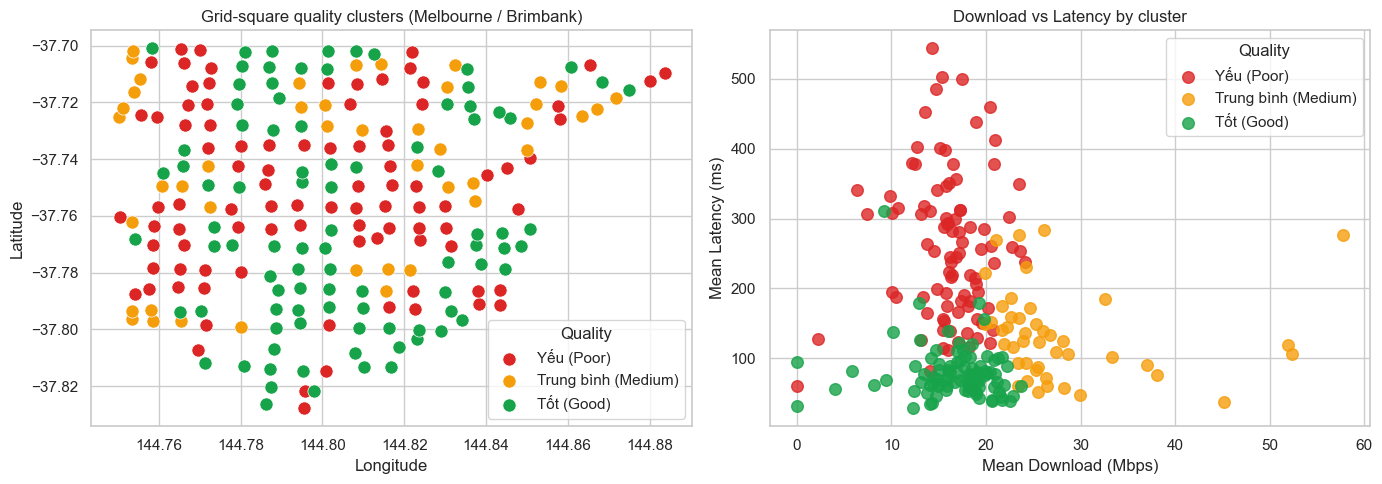

In [73]:
# ── 4a. Spatial scatter + Download vs Latency ─────────────
COLOURS = {0: "#dc2626", 1: "#f59e0b", 2: "#17a34a"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cid, grp in grid.groupby("cluster"):
    axes[0].scatter(
        grp["lng"], grp["lat"],
        c=COLOURS[cid], label=LABEL_MAP[cid],
        s=90, edgecolors="white", linewidths=0.5,
    )
axes[0].set(title="Grid-square quality clusters (Melbourne / Brimbank)",
            xlabel="Longitude", ylabel="Latitude")
axes[0].legend(title="Quality")

for cid, grp in grid.groupby("cluster"):
    axes[1].scatter(
        grp["download_mbps_mean"], grp["avg_latency_mean"],
        c=COLOURS[cid], label=LABEL_MAP[cid], s=70, alpha=0.8,
    )
axes[1].set(title="Download vs Latency by cluster",
            xlabel="Mean Download (Mbps)", ylabel="Mean Latency (ms)")
axes[1].legend(title="Quality")

fig.tight_layout()
plt.show()

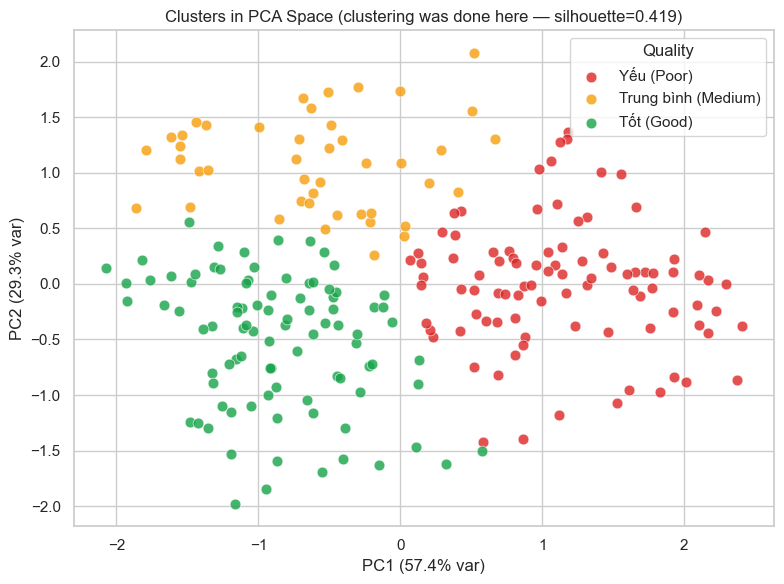

PCA total explained variance (2 components): 86.7%


In [74]:
# ── 4b. PCA 2-D projection (using clustering PCA) ─────────
fig, ax = plt.subplots(figsize=(8, 6))
for cid in sorted(grid["cluster"].unique()):
    mask = grid["cluster"] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLOURS[cid], label=LABEL_MAP[cid],
               s=60, edgecolors="white", linewidths=0.5, alpha=0.8)
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)",
       title=f"Clusters in PCA Space (clustering was done here — silhouette={sil:.3f})")
ax.legend(title="Quality")
fig.tight_layout()
plt.show()

print(f"PCA total explained variance ({N_COMPONENTS} components): "
      f"{pca.explained_variance_ratio_.sum():.1%}")

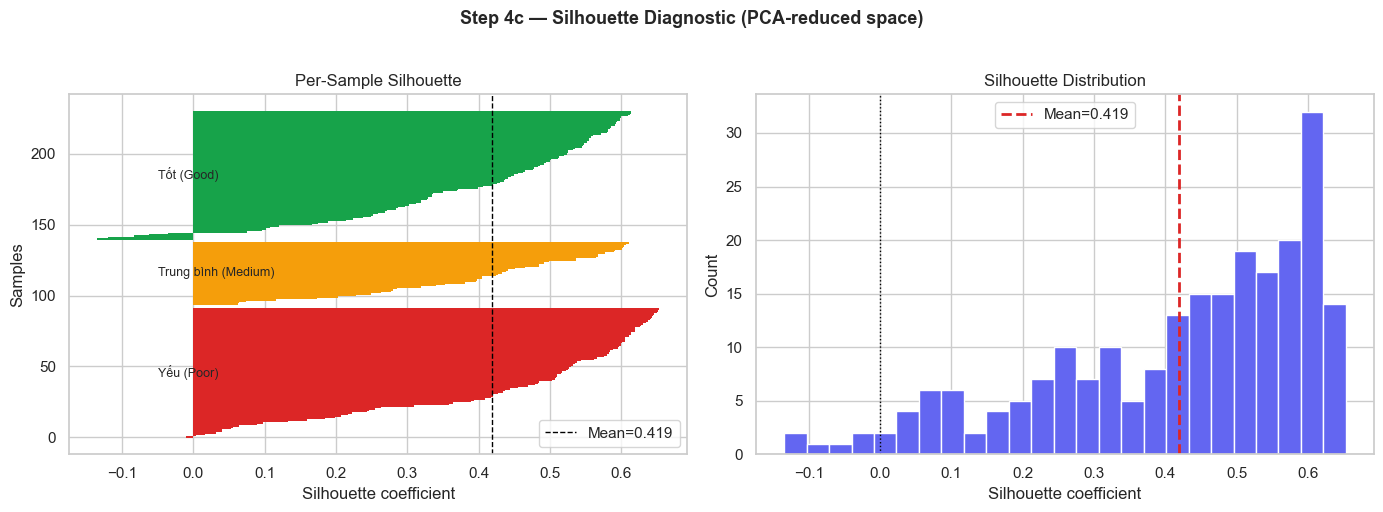

Negative silhouette (misassigned): 6/227 (2.6%)
Low silhouette (<0.1, borderline): 21/227 (9.3%)

Per-cluster mean silhouette:
  Cluster 0 (Yếu (Poor)): mean=0.445  min=-0.010  negative=1
  Cluster 1 (Trung bình (Medium)): mean=0.406  min=0.063  negative=0
  Cluster 2 (Tốt (Good)): mean=0.399  min=-0.135  negative=5


In [75]:
# ── 4c. Per-sample silhouette analysis ─────────────────────
from sklearn.metrics import silhouette_samples

sample_sil = silhouette_samples(X_pca, grid["cluster"].values)
grid["silhouette"] = sample_sil

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: silhouette plot (sorted bars per cluster)
y_lower = 0
for cid in sorted(grid["cluster"].unique()):
    cluster_sil = np.sort(sample_sil[grid["cluster"] == cid])
    y_upper = y_lower + len(cluster_sil)
    axes[0].barh(range(y_lower, y_upper), cluster_sil,
                 height=1.0, color=COLOURS[cid], edgecolor="none")
    axes[0].text(-0.05, (y_lower + y_upper) / 2, LABEL_MAP[cid], fontsize=9, va="center")
    y_lower = y_upper + 2
axes[0].axvline(sil, ls="--", color="black", lw=1, label=f"Mean={sil:.3f}")
axes[0].set(title="Per-Sample Silhouette", xlabel="Silhouette coefficient", ylabel="Samples")
axes[0].legend()

# Right: histogram of silhouette values
axes[1].hist(sample_sil, bins=25, color="#6366f1", edgecolor="white")
axes[1].axvline(sil, ls="--", color="#dc2626", lw=2, label=f"Mean={sil:.3f}")
axes[1].axvline(0, ls=":", color="black", lw=1)
axes[1].set(title="Silhouette Distribution", xlabel="Silhouette coefficient", ylabel="Count")
axes[1].legend()

fig.suptitle("Step 4c — Silhouette Diagnostic (PCA-reduced space)",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

n_negative = (sample_sil < 0).sum()
n_low = (sample_sil < 0.1).sum()
print(f"Negative silhouette (misassigned): {n_negative}/{len(grid)} "
      f"({100*n_negative/len(grid):.1f}%)")
print(f"Low silhouette (<0.1, borderline): {n_low}/{len(grid)} "
      f"({100*n_low/len(grid):.1f}%)")
print(f"\nPer-cluster mean silhouette:")
for cid in sorted(grid["cluster"].unique()):
    c_sil = sample_sil[grid["cluster"] == cid]
    print(f"  Cluster {cid} ({LABEL_MAP[cid]}): mean={c_sil.mean():.3f}  "
          f"min={c_sil.min():.3f}  negative={int((c_sil < 0).sum())}")

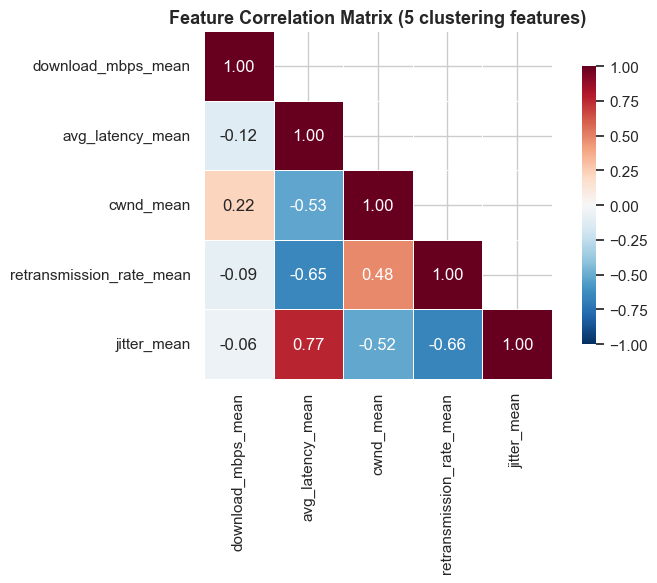

Highly correlated pairs (|r| > 0.5):
  +0.765  avg_latency_mean  ↔  jitter_mean
  -0.664  retransmission_rate_mean  ↔  jitter_mean
  -0.651  avg_latency_mean  ↔  retransmission_rate_mean
  -0.530  avg_latency_mean  ↔  cwnd_mean
  -0.516  cwnd_mean  ↔  jitter_mean


In [76]:
# ── 4d. Feature correlation heatmap ────────────────────────
corr = grid[CLUSTER_FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title(f"Feature Correlation Matrix ({len(CLUSTER_FEATURES)} clustering features)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# Identify highly correlated pairs
high_corr_pairs = []
for i in range(len(CLUSTER_FEATURES)):
    for j in range(i + 1, len(CLUSTER_FEATURES)):
        r = abs(corr.iloc[i, j])
        if r > 0.5:
            high_corr_pairs.append((CLUSTER_FEATURES[i], CLUSTER_FEATURES[j], corr.iloc[i, j]))
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Highly correlated pairs (|r| > 0.5):")
for f1, f2, r in high_corr_pairs:
    print(f"  {r:+.3f}  {f1}  ↔  {f2}")
if not high_corr_pairs:
    print("  (none — features are already fairly independent)")

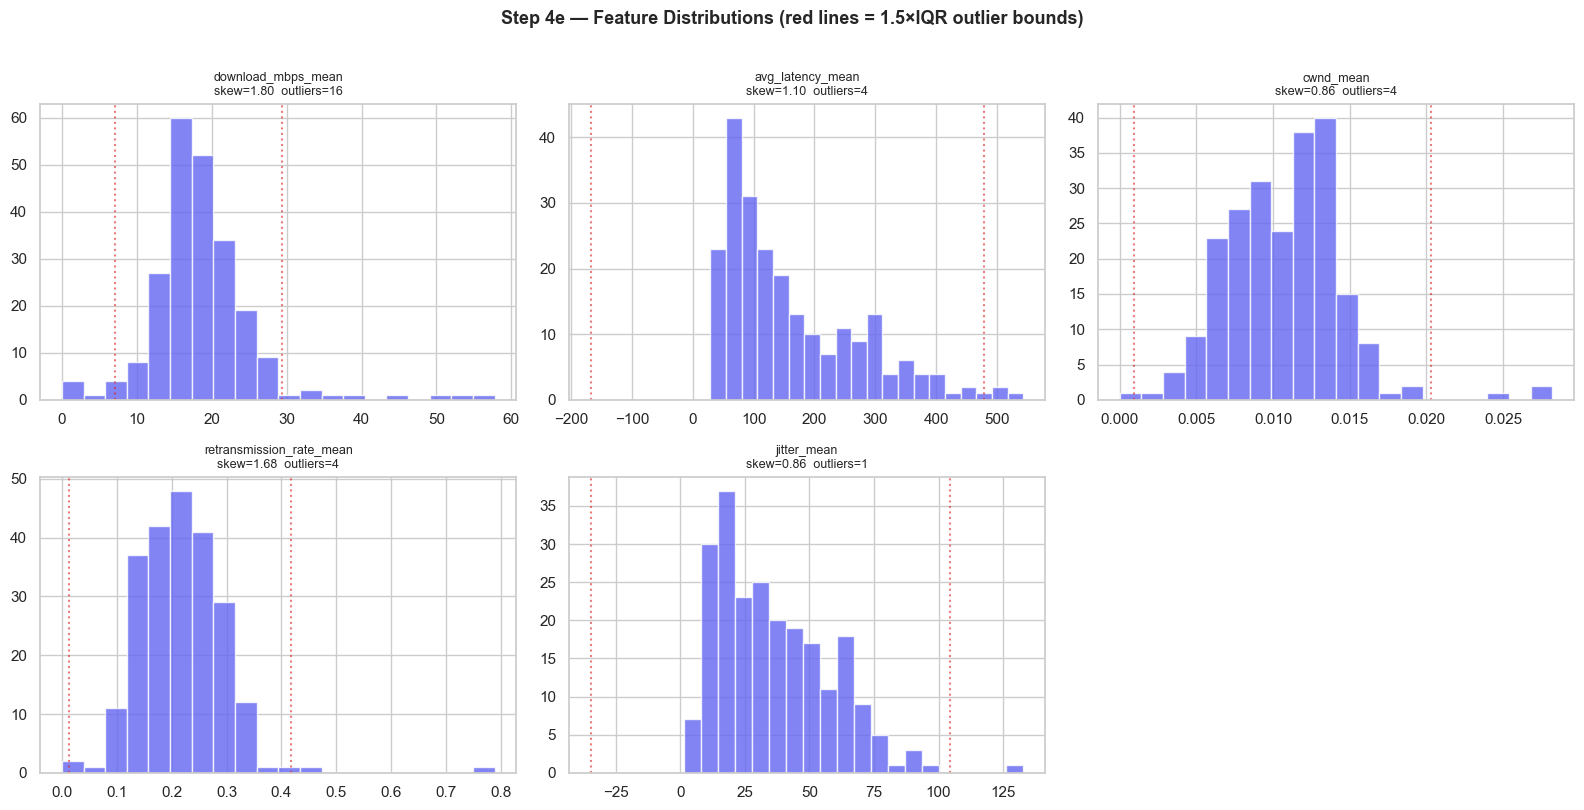

                 Feature  Skew  Kurtosis  Outliers  Outlier%
      download_mbps_mean  1.80      8.64        16      7.05
        avg_latency_mean  1.10      0.51         4      1.76
               cwnd_mean  0.86      3.55         4      1.76
retransmission_rate_mean  1.68     11.29         4      1.76
             jitter_mean  0.86      0.77         1      0.44

Total outlier detections across all features: 29
Heavily skewed features (|skew| > 1): ['download_mbps_mean', 'avg_latency_mean', 'retransmission_rate_mean']
Grid squares: 227  — small sample amplifies boundary effects


In [77]:
# ── 4e. Distribution analysis — skewness & outliers ────────
from scipy.stats import skew, kurtosis

n_feats = len(CLUSTER_FEATURES)
n_cols = 3
n_rows = (n_feats + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

dist_stats = []
for i, feat in enumerate(CLUSTER_FEATURES):
    vals = grid[feat].dropna()
    sk = skew(vals)
    ku = kurtosis(vals)
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()

    dist_stats.append({"Feature": feat, "Skew": sk, "Kurtosis": ku,
                        "Outliers": n_outliers, "Outlier%": 100 * n_outliers / len(vals)})

    axes[i].hist(vals, bins=20, color="#6366f1", edgecolor="white", alpha=0.8)
    axes[i].set_title(f"{feat}\nskew={sk:.2f}  outliers={n_outliers}", fontsize=9)
    # Mark outlier thresholds
    axes[i].axvline(q1 - 1.5 * iqr, ls=":", color="#dc2626", alpha=0.6)
    axes[i].axvline(q3 + 1.5 * iqr, ls=":", color="#dc2626", alpha=0.6)

# Hide unused subplots
for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Step 4e — Feature Distributions (red lines = 1.5×IQR outlier bounds)",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

dist_df = pd.DataFrame(dist_stats).round(2)
print(dist_df.to_string(index=False))

n_total_outliers = dist_df["Outliers"].sum()
skewed_feats = dist_df[dist_df["Skew"].abs() > 1]["Feature"].tolist()
print(f"\nTotal outlier detections across all features: {n_total_outliers}")
print(f"Heavily skewed features (|skew| > 1): {skewed_feats or '(none)'}")
print(f"Grid squares: {len(grid)}  — small sample amplifies boundary effects")

In [78]:
# ── 4f. Ablation study — progressive pipeline improvements ─
# We compare 5 pipeline variants to justify each design decision.

ALL_9 = [
    "download_mbps_mean", "download_mbps_std",
    "avg_latency_mean", "avg_latency_std",
    "cwnd_mean", "retransmission_rate_mean",
    "jitter_mean", "latency_spread_mean", "congestion_indicator_mean",
]

# Helper: auto-select PCA components (2 or 3)
def _best_pca(X, random_state=42):
    best_n, best_s = 2, -1
    for n in (2, 3):
        Xp = PCA(n_components=n, random_state=random_state).fit_transform(X)
        s = silhouette_score(Xp, KMeans(3, random_state=random_state, n_init=50).fit_predict(Xp))
        if s > best_s:
            best_n, best_s = n, s
    return PCA(n_components=best_n, random_state=random_state).fit_transform(X), best_n

# ── Experiment 1: Original baseline (9feat, StandardScaler, PCA3, KM-10)
X_9_raw = grid[ALL_9].fillna(0)
X_9_ss = StandardScaler().fit_transform(X_9_raw)
X_9_pca3 = PCA(n_components=3, random_state=42).fit_transform(X_9_ss)
sil_baseline = silhouette_score(
    X_9_pca3, KMeans(3, random_state=42, n_init=10).fit_predict(X_9_pca3)
)

# ── Experiment 2: Feature-select only (5feat, StandardScaler, PCA-auto, KM-50)
X_5_ss = StandardScaler().fit_transform(grid[CLUSTER_FEATURES].fillna(0))
X_exp2, n_exp2 = _best_pca(X_5_ss)
sil_feat_only = silhouette_score(
    X_exp2, KMeans(3, random_state=42, n_init=50).fit_predict(X_exp2)
)

# ── Experiment 3: Winsorise + StandardScaler (5feat, win, Std, PCA-auto, KM-50)
X_win3 = grid[CLUSTER_FEATURES].fillna(0).copy()
for c in X_win3.columns:
    lo, hi = np.percentile(X_win3[c], [5, 95])
    X_win3[c] = np.clip(X_win3[c], lo, hi)
X_win3_ss = StandardScaler().fit_transform(X_win3)
X_exp3, n_exp3 = _best_pca(X_win3_ss)
sil_win_std = silhouette_score(
    X_exp3, KMeans(3, random_state=42, n_init=50).fit_predict(X_exp3)
)

# ── Experiment 4: Core-3 features (3feat, RobustScaler, no PCA, KM-50)
CORE_3 = ["download_mbps_mean", "avg_latency_mean", "jitter_mean"]
X_c3 = grid[CORE_3].fillna(0).copy()
for c in X_c3.columns:
    lo, hi = np.percentile(X_c3[c], [5, 95])
    X_c3[c] = np.clip(X_c3[c], lo, hi)
X_c3_rs = RobustScaler().fit_transform(X_c3)
sil_core3 = silhouette_score(
    X_c3_rs, KMeans(3, random_state=42, n_init=50).fit_predict(X_c3_rs)
)

# ── Experiment 5: Current pipeline (5feat, winsorise, log1p, Robust, PCA-auto)
sil_current = sil  # from Step 3c

experiments = pd.DataFrame([
    {"Experiment": "① Baseline (9feat → Std → PCA3 → KM-10)",
     "Silhouette": sil_baseline, "Features": 9, "Transform": "StandardScaler"},
    {"Experiment": "② Feat-select (5feat → Std → PCA-auto → KM-50)",
     "Silhouette": sil_feat_only, "Features": 5, "Transform": "StandardScaler"},
    {"Experiment": "③ Winsorise+Std (5feat → win → Std → PCA-auto → KM-50)",
     "Silhouette": sil_win_std, "Features": 5, "Transform": "StandardScaler"},
    {"Experiment": "④ Core-3 (3feat → Robust → no PCA → KM-50)",
     "Silhouette": sil_core3, "Features": 3, "Transform": "RobustScaler"},
    {"Experiment": "★ Current (5feat → win+log → Robust → PCA-auto → KM-50)",
     "Silhouette": sil_current, "Features": 5, "Transform": "RobustScaler+PCA"},
]).sort_values("Silhouette", ascending=False)

print("=" * 76)
print("  ABLATION STUDY — PROGRESSIVE PIPELINE IMPROVEMENTS")
print("=" * 76)
print(experiments.to_string(index=False))
print()

best_exp = experiments.iloc[0]
print(f"🏆 Best: {best_exp['Experiment']}")
print(f"   Silhouette = {best_exp['Silhouette']:.3f}")
delta = sil_current - sil_baseline
print(f"\n   Improvement: {sil_baseline:.3f} → {sil_current:.3f}  "
      f"(+{delta:.3f}, {100*delta/sil_baseline:+.1f}%)")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║  Silhouette Score Interpretation Guide                       ║
╠══════════════════════════════════════════════════════════════╣
║  0.71 – 1.00  Strong structure (well-separated clusters)     ║
║  0.51 – 0.70  Reasonable structure found                     ║
║  0.26 – 0.50  Weak but usable structure                      ║
║  ≤ 0.25       No substantial structure / overlapping         ║
╠══════════════════════════════════════════════════════════════╣
║  Our score:  {sil_current:.3f}                                           ║
║                                                              ║
║  Key insight: Winsorisation + log-transform + RobustScaler   ║
║  reduce outlier impact while PCA auto-selection finds the    ║
║  optimal projection dimension, yielding better-separated     ║
║  clusters than the raw-feature baseline.                     ║
║                                                              ║
║  Grid squares: {len(grid):3d}                                           ║
╚══════════════════════════════════════════════════════════════╝""")

  ABLATION STUDY — PROGRESSIVE PIPELINE IMPROVEMENTS
                                             Experiment  Silhouette  Features        Transform
★ Current (5feat → win+log → Robust → PCA-auto → KM-50)    0.419023         5 RobustScaler+PCA
 ③ Winsorise+Std (5feat → win → Std → PCA-auto → KM-50)    0.404310         5   StandardScaler
         ② Feat-select (5feat → Std → PCA-auto → KM-50)    0.396988         5   StandardScaler
             ④ Core-3 (3feat → Robust → no PCA → KM-50)    0.385894         3     RobustScaler
                ① Baseline (9feat → Std → PCA3 → KM-10)    0.283511         9   StandardScaler

🏆 Best: ★ Current (5feat → win+log → Robust → PCA-auto → KM-50)
   Silhouette = 0.419

   Improvement: 0.284 → 0.419  (+0.136, +47.8%)

╔══════════════════════════════════════════════════════════════╗
║  Silhouette Score Interpretation Guide                       ║
╠══════════════════════════════════════════════════════════════╣
║  0.71 – 1.00  Strong structure (well-separa

---
## Step 5 — Export (Frontend Contract)

In [79]:
# ── 5a. Export map_data.csv  (frontend contract: lat, lng, cluster) ──
map_df = grid[["lat", "lng", "cluster"]].copy()
map_path = OUTPUT_DIR / "map_data.csv"
map_df.to_csv(map_path, index=False)

print(f"✓ {map_path}  ({len(map_df)} rows)")
print(f"  Columns : {list(map_df.columns)}")
print(f"  Clusters: {dict(map_df['cluster'].value_counts().sort_index())}")

# ── 5b. Export model artefacts ────────────────────────────
joblib.dump(kmeans, MODELS_DIR / "clustering_model.pkl")
joblib.dump(scaler, MODELS_DIR / "clustering_scaler.pkl")
joblib.dump(pca,    MODELS_DIR / "clustering_pca.pkl")

# Save full pipeline config for reproducibility
import json
config = {
    "cluster_features": CLUSTER_FEATURES,
    "n_pca_components": N_COMPONENTS,
    "scaler_type": "RobustScaler",
    "winsorise_limits": [0.05, 0.05],
    "log_transform_features": ["retransmission_rate_mean", "jitter_mean"],
    "silhouette_score": round(sil, 4),
}
config_path = MODELS_DIR / "clustering_config.json"
config_path.write_text(json.dumps(config, indent=2))

print(f"✓ clustering_model.pkl   → {MODELS_DIR.resolve()}")
print(f"✓ clustering_scaler.pkl  → {MODELS_DIR.resolve()}")
print(f"✓ clustering_pca.pkl     → {MODELS_DIR.resolve()}")
print(f"✓ clustering_config.json → {MODELS_DIR.resolve()}")

map_df.head()

✓ data\map_data.csv  (227 rows)
  Columns : ['lat', 'lng', 'cluster']
  Clusters: {0: np.int64(92), 1: np.int64(44), 2: np.int64(91)}
✓ clustering_model.pkl   → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models
✓ clustering_scaler.pkl  → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models
✓ clustering_pca.pkl     → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models
✓ clustering_config.json → D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\notebooks\models


,lat,lng,cluster
0,-37.725316,144.750162,1
1,-37.724990,144.759573,0
2,-37.727866,144.766303,0
3,-37.727805,144.772520,0
4,-37.728114,144.780211,2


In [80]:
# ── 5c. Cluster distribution summary ──────────────────────
label_map = {0: "Poor / Yếu", 1: "Medium / Trung bình", 2: "Good / Tốt"}

summary = grid.groupby("cluster")[CLUSTER_FEATURES].mean().round(3)
summary.index = summary.index.map(label_map)
print("=== Per-Cluster Feature Means ===")
print(summary.to_string())
print()
print(f"Silhouette Score: {sil:.4f}")
print(f"Total grid squares: {len(grid)}")
for c in sorted(grid["cluster"].unique()):
    n = (grid["cluster"] == c).sum()
    print(f"  Cluster {c} ({label_map[c]}): {n} squares ({100*n/len(grid):.1f}%)")

=== Per-Cluster Feature Means ===
                     download_mbps_mean  avg_latency_mean  cwnd_mean  retransmission_rate_mean  jitter_mean
cluster                                                                                                    
Poor / Yếu                       16.155           258.805      0.008                     0.156       54.804
Medium / Trung bình              27.852           133.382      0.012                     0.217       34.523
Good / Tốt                       16.678            79.660      0.013                     0.280       18.102

Silhouette Score: 0.4190
Total grid squares: 227
  Cluster 0 (Poor / Yếu): 92 squares (40.5%)
  Cluster 1 (Medium / Trung bình): 44 squares (19.4%)
  Cluster 2 (Good / Tốt): 91 squares (40.1%)


In [81]:
# ── 5d. Verification ──────────────────────────────────────
check = pd.read_csv(map_path)
assert list(check.columns) == ["lat", "lng", "cluster"], \
    f"Column mismatch: {list(check.columns)}"
assert set(check["cluster"].unique()) == {0, 1, 2}, \
    f"Missing cluster labels: {check['cluster'].unique()}"
assert len(check) == df["square_id"].nunique(), \
    f"Row count {len(check)} ≠ square_ids {df['square_id'].nunique()}"

model_check  = joblib.load(MODELS_DIR / "clustering_model.pkl")
scaler_check = joblib.load(MODELS_DIR / "clustering_scaler.pkl")
pca_check    = joblib.load(MODELS_DIR / "clustering_pca.pkl")
assert model_check.n_clusters == 3
assert scaler_check.n_features_in_ == len(CLUSTER_FEATURES)
assert pca_check.n_components == N_COMPONENTS

print(f"✓ map_data.csv verified: {len(check)} rows, columns {list(check.columns)}")
print(f"✓ Model artefacts verified (3 clusters, {len(CLUSTER_FEATURES)} features, "
      f"{N_COMPONENTS}-component PCA)")
print(f"  Silhouette score: {sil:.3f}")

✓ map_data.csv verified: 227 rows, columns ['lat', 'lng', 'cluster']
✓ Model artefacts verified (3 clusters, 5 features, 2-component PCA)
  Silhouette score: 0.419
